In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e12/sample_submission.csv
/kaggle/input/playground-series-s4e12/train.csv
/kaggle/input/playground-series-s4e12/test.csv


In [2]:
df=pd.read_csv("/kaggle/input/playground-series-s4e12/train.csv")

In [31]:
def wrangle(filepath):
    df=pd.read_csv(filepath)
    df.drop(columns=["id","Policy Start Date"],inplace=True)
    return df

In [3]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [4]:
df.shape

(1200000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [6]:
df.isnull().sum().sort_values(ascending=False)

Previous Claims         364029
Occupation              358075
Credit Score            137882
Number of Dependents    109672
Customer Feedback        77824
Health Score             74076
Annual Income            44949
Age                      18705
Marital Status           18529
Vehicle Age                  6
Insurance Duration           1
Gender                       0
id                           0
Location                     0
Policy Type                  0
Education Level              0
Policy Start Date            0
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [7]:
# ── Missing values audit ────────────────────────────────────────────────────
def missing_report(df):
    miss = df.isnull().sum()
    pct  = 100 * miss / len(df)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    report=report[report["missing_pct"] > 0].sort_values("missing_pct",ascending=False)
    return report

miss = missing_report(df)
miss

,missing_count,missing_pct
Previous Claims,364029,30.335750
Occupation,358075,29.839583
Credit Score,137882,11.490167
Number of Dependents,109672,9.139333
Customer Feedback,77824,6.485333
Health Score,74076,6.173000
Annual Income,44949,3.745750
Age,18705,1.558750
Marital Status,18529,1.544083
Vehicle Age,6,0.000500


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.200000e+06,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,5.999995e+05,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,3.464103e+05,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,0.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,2.999998e+05,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,5.999995e+05,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,8.999992e+05,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,1.199999e+06,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

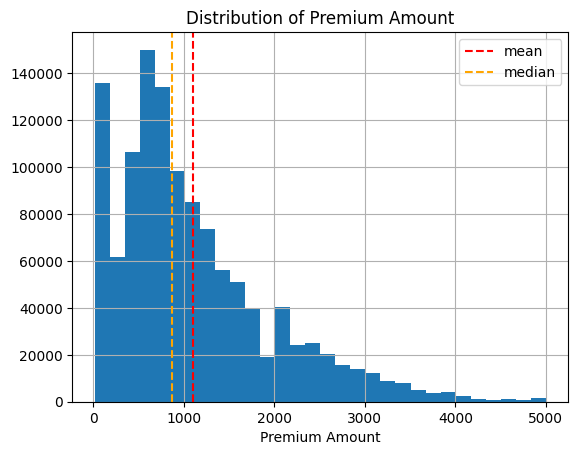

In [11]:
df["Premium Amount"].hist(bins=30)
plt.title("Distribution of Premium Amount")
plt.xlabel("Premium Amount")
plt.axvline(df["Premium Amount"].mean(),color="red",linestyle="--",label="mean")
plt.axvline(df["Premium Amount"].median(),color="orange",linestyle="--",label="median")
plt.legend()

In [12]:
from scipy.stats import skew

In [13]:
skew(df["Premium Amount"])

np.float64(1.2409139421441986)

{'whiskers': [<matplotlib.lines.Line2D at 0x7bf916c34800>,
 'caps': [<matplotlib.lines.Line2D at 0x7bf916cc8d40>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bf916cc8530>],
 'medians': [<matplotlib.lines.Line2D at 0x7bf916cc9310>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bf916cc95e0>],
 'means': []}

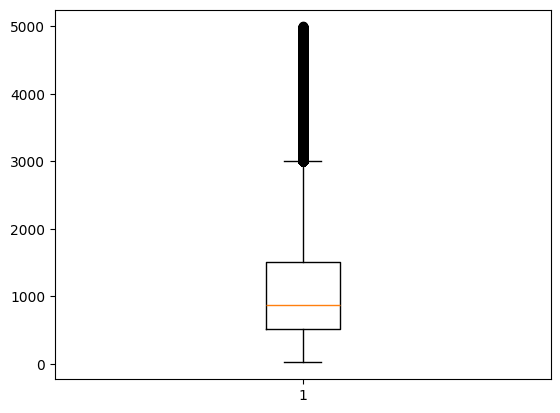

In [14]:
plt.boxplot(df["Premium Amount"],vert=True)

In [15]:
Q1 = df["Premium Amount"].quantile(0.25)
Q3 = df["Premium Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
outliers = df["Premium Amount"][(df["Premium Amount"] < lower) | (df["Premium Amount"]> upper)]
print(f"🔍 Outlier Analysis (3×IQR method):")
print(f"  IQR range: [{lower:.2f}, {upper:.2f}]")
print(f"  Outliers found: {len(outliers):,} ({100*len(outliers)/len(df["Premium Amount"]):.1f}%)")
print()

🔍 Outlier Analysis (3×IQR method):
  IQR range: [-2471.00, 4494.00]
  Outliers found: 3,702 (0.3%)



In [16]:
df["log_target"]=np.log1p(df["Premium Amount"])

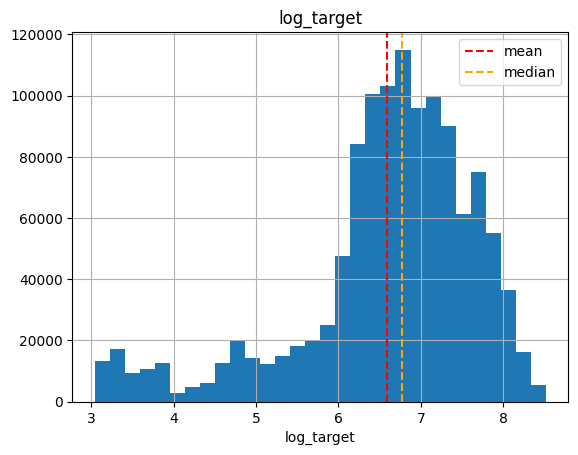

In [17]:
df["log_target"].hist(bins=30)
plt.title("log_target")
plt.xlabel("log_target")
plt.axvline(df["log_target"].mean(),color="red",linestyle="--",label="mean")
plt.axvline(df["log_target"].median(),color="orange",linestyle="--",label="median")
plt.legend()

In [18]:
Q1 = df["log_target"].quantile(0.25)
Q3 = df["log_target"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
outliers = df["log_target"][(df["log_target"] < lower) | (df["log_target"]> upper)]
print(f"🔍 Outlier Analysis (3×IQR method):")
print(f"  IQR range: [{lower:.2f}, {upper:.2f}]")
print(f"  Outliers found: {len(outliers):,} ({100*len(outliers)/len(df["Premium Amount"]):.1f}%)")
print()

🔍 Outlier Analysis (3×IQR method):
  IQR range: [3.02, 10.55]
  Outliers found: 0 (0.0%)



<Axes: >

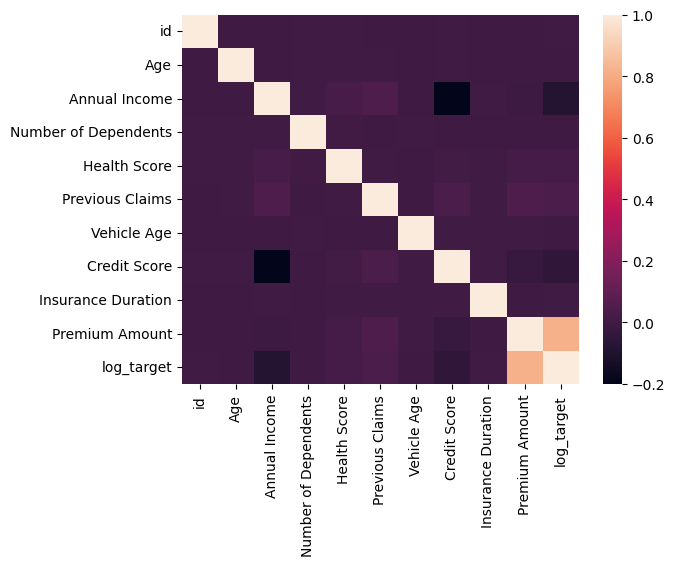

In [19]:
sns.heatmap(df.select_dtypes("number").corr())

In [20]:
df.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount', 'log_target'],
      dtype='object')

<Axes: xlabel='Gender', ylabel='count'>

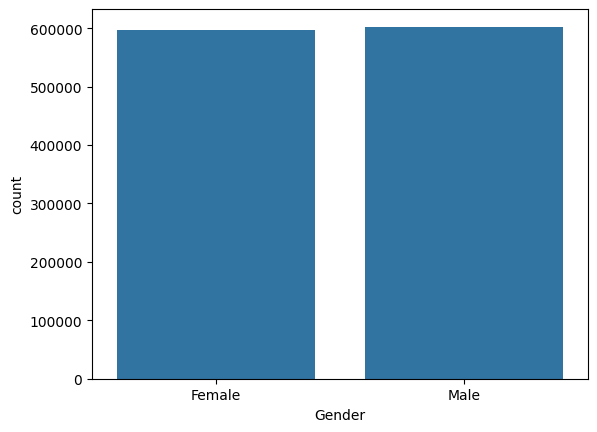

In [21]:
sns.countplot(x=df["Gender"])

In [22]:
df.drop(columns=["id","Policy Start Date"],inplace=True)

In [23]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Customer Feedback',
       'Smoking Status', 'Exercise Frequency', 'Property Type',
       'Premium Amount', 'log_target'],
      dtype='object')

In [24]:
X= df[['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Customer Feedback',
       'Smoking Status', 'Exercise Frequency', 'Property Type']]
y=df["Premium Amount"]

In [32]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [27]:
from sklearn.compose import ColumnTransformer

# Identify column types in training data
num_cols_train = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()



numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   
    ('scaler',  RobustScaler())                       
])


categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols_train),
    ('cat', categorical_pipeline, cat_cols_train)
], remainder='drop')


X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)


In [37]:
model=make_pipeline(
    preprocessor,
    XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,  # Fraction of features per tree
        reg_alpha=0.1,          # L1 regularization
        reg_lambda=1.0,         # L2 regularization
        eval_metric='rmse',
        random_state=42,
        verbosity=0
    )
)
model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Annual Income',
                                                   'Number of Dependents',
                                                   'Health Score',
                                                   'Previous Claims',
                                                   'Vehicle Age',
                                                   'Credit Score',
                                                   'Insurance Duration']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [38]:
model2_pred_train=model2.predict(X_train_proc)
model2_pred_test=model2.predict(X_test_proc)

In [39]:
model2_train_mae=mean_absolute_error(y_train,model2_pred_train)
model2_test_mae=mean_absolute_error(y_test,model2_pred_test)
dt_r2_score=r2_score(y_test,model2_pred_test)

print(f"Training MAE: {model2_train_mae}")
print(f"Test MAE: {model2_test_mae}")
print(f" r2_score: {dt_r2_score}")

Training MAE: 640.8970654921637
Test MAE: 645.9012870427449
 r2_score: 0.04001441819639395


In [41]:
Test= wrangle("/kaggle/input/playground-series-s4e12/test.csv")

In [42]:
Test.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,Poor,Yes,Weekly,House
1,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,Good,Yes,Rarely,Apartment
2,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,Average,Yes,Monthly,Condo
3,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,Poor,Yes,Daily,House
4,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,Average,No,Weekly,House


In [43]:
test=model.predict(Test)

In [45]:
df2=pd.read_csv("/kaggle/input/playground-series-s4e12/test.csv")
df2.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House
1,1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment
2,1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo
3,1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House
4,1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House


In [48]:
final=pd.DataFrame({
    "Premium Amount":test
},index=df2["id"])

final.head()

,Premium Amount
id,
1200000,1493.571533
1200001,1128.621948
1200002,1072.353760
1200003,1103.562622
1200004,1027.115967


In [50]:
final.to_csv("Premium_amount(1).csv")